In [ ]:
from google.colab import drive
import json
import os

# Mount drive
drive.mount('/content/drive')

# Define paths
csv_data_path = '/content/drive/MyDrive/DSA210-Project/data/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df = pd.read_csv(csv_data_path + 'pre_cross_val_ml_dataset.csv')
print(df.head())

          Pokemon         Ability_1 Ability_2 Ability_3  Hazard  Pivot  Setup  \
0        koraidon  Orichalcum Pulse       NaN       NaN       0      1      1   
1  zacian-crowned    Intrepid Sword       NaN       NaN       0      0      1   
2          kyogre           Drizzle       NaN       NaN       0      0      1   
3          arceus         Multitype       NaN       NaN       0      0      1   
4           ho-oh       Regenerator  Pressure       NaN       0      0      0   

   Recovery  Utility  Priority  TypeDefScore  TypeOffScore   HP  Atk  Def  \
0         0        0         0           4.0          15.5  100  135  115   
1         0        0         0          36.5          13.0   92  150  115   
2         0        1         0          12.0           6.0  100  100   90   
3         1        1         1          11.0          -0.5  120  120  120   
4         1        1         0          16.0          14.0  106  130   90   

   SpA  SpD  CoverageScore  SpeedTier   Tier  
0  

In [ ]:
impactful_abilities = ['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts',
                       'Regenerator', 'Speed Boost', 'Unaware', 'Technician', 'Tinted Lens'
                       ]
print(impactful_abilities)

['Intimidate', 'Magic Guard', 'Prankster', 'Drizzle', 'Drought', 'Huge Power', 'Magic Bounce', 'Snow Warning', 'Guts', 'Regenerator', 'Speed Boost', 'Unaware', 'Technician', 'Tinted Lens']


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_validate

# Define the order from strongest to weakest
tier_map = {
    "Ubers": 0,
    "OU": 1,
    "UU": 2,
    "RU": 3,
    "NU": 4,
    "PU": 5,
    "ZU": 6
}

# Apply the map to your target variable
y = df['Tier'].map(tier_map)
X = df.drop(columns=['Tier'])

# Setup K-Fold
kf = StratifiedKFold(n_splits=5, shuffle=True)
fold_accuracies = []
fold_f1_scores = []

all_y_true = []
all_y_pred = []

# Initialize the baseline (Most Frequent Class) i.e. ZU
baseline_model = DummyClassifier(strategy="most_frequent")

# Run Cross-Validation on the Baseline
baseline_results = cross_validate(
    baseline_model,
    X,
    y,
    cv=kf,
    scoring=['accuracy', 'f1_macro']
)

print(f"Baseline Accuracy: {baseline_results['test_accuracy'].mean():.4f}")
print(f"Baseline F1 (Macro): {baseline_results['test_f1_macro'].mean():.4f}")

Baseline Accuracy: 0.4172
Baseline F1 (Macro): 0.0841


In [ ]:
for train_index, test_index in kf.split(X,y):
    # Unpack Train/Test
    X_train, X_test = X.iloc[train_index].copy(), X.iloc[test_index].copy()
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    '''
    # 1. Count frequencies across all 3 ability slots
    # We drop 'None' so we don't count empty slots as an ability
    stacked_abilities = pd.concat([X_train['Ability_1'], X_train['Ability_2'], X_train['Ability_3']]).dropna()
    counts = stacked_abilities.value_counts()


    # 2. Filter: Must be in your impactful list AND occur >= 10 times in this fold
    selected_abilities = [
        ability for ability in impactful_abilities
        if counts.get(ability, 0) >= 7
    ]

    # 3. Create Binary Features
    for ab in selected_abilities:
        # If 'ab' is in ANY of the three columns, the feature is 1, else 0
        X_train[f"{ab}"] = X_train[['Ability_1', 'Ability_2', 'Ability_3']].eq(ab).any(axis=1).astype(int)
        X_test[f"{ab}"] = X_test[['Ability_1', 'Ability_2', 'Ability_3']].eq(ab).any(axis=1).astype(int)
    '''
    # 4. Clean up columns for XGBoost
    # We must remove all string columns before training
    X_train_final = X_train.drop(columns=['Pokemon', 'Ability_1', 'Ability_2', 'Ability_3'])
    X_test_final = X_test.drop(columns=['Pokemon', 'Ability_1', 'Ability_2', 'Ability_3'])

    # 5. Train & Evaluate
    model = XGBClassifier(objective='multi:softprob', eval_metric='mlogloss')
    model.fit(X_train_final, y_train)

    # ... rest of evaluation ...
    preds = model.predict(X_test_final)

    all_y_true.extend(y_test)
    all_y_pred.extend(preds)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='macro')

    fold_accuracies.append(acc)
    fold_f1_scores.append(f1)
    print(f"Fold Accuracy: {acc:.4f} | Fold F1: {f1:.4f} |Features: {X_train_final.shape[1]}")

print(f"\nAverage Cross-Validation Accuracy: {np.mean(fold_accuracies):.4f}")
print(f"Average Cross-Validation F1 Score: {np.mean(fold_f1_scores):.4f}")


Fold Accuracy: 0.5269 | Fold F1: 0.3115 |Features: 15
Fold Accuracy: 0.5376 | Fold F1: 0.2936 |Features: 15
Fold Accuracy: 0.5269 | Fold F1: 0.3549 |Features: 15
Fold Accuracy: 0.5484 | Fold F1: 0.2980 |Features: 15
Fold Accuracy: 0.4839 | Fold F1: 0.3469 |Features: 15

Average Cross-Validation Accuracy: 0.5247
Average Cross-Validation F1 Score: 0.3210


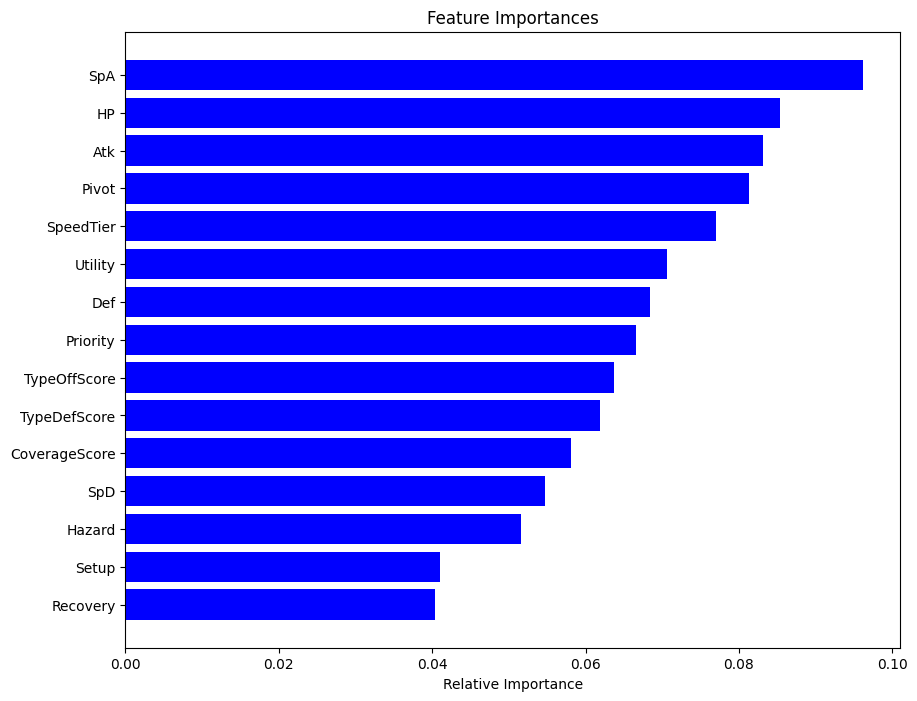

In [ ]:
import matplotlib.pyplot as plt

# 1. Get feature importance
importances = model.feature_importances_
features = X_train_final.columns
indices = np.argsort(importances)

# 2. Plot it
plt.figure(figsize=(10, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

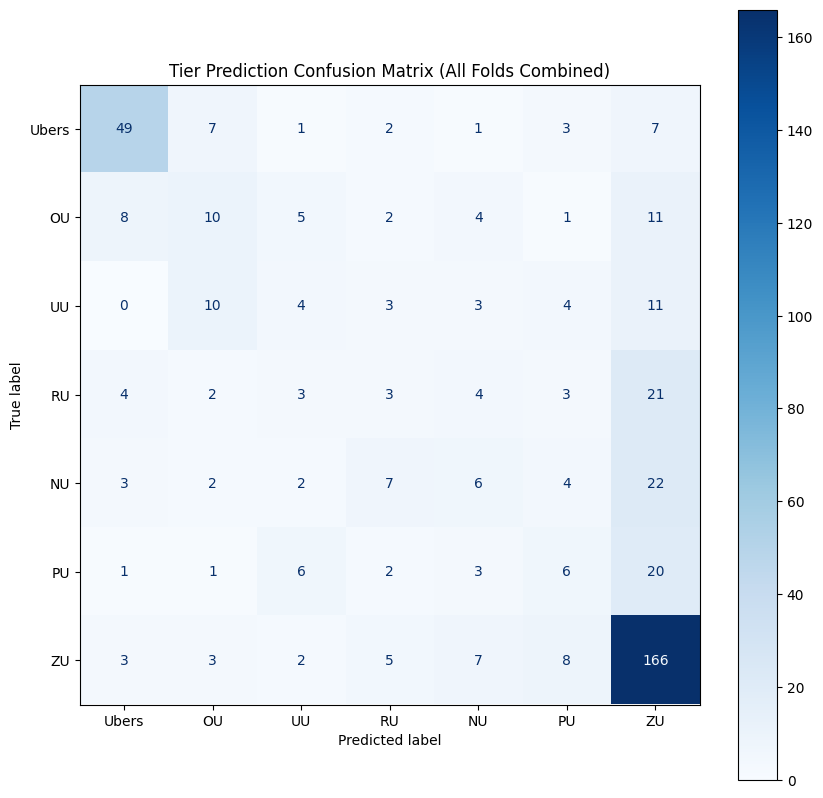

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the matrix
cm = confusion_matrix(all_y_true, all_y_pred)

# Set up the display
# We use the keys from your tier_map as labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=tier_map.keys())

# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Tier Prediction Confusion Matrix (All Folds Combined)')
plt.show()